In [1]:
from experiments.coupled_lin_osc import CoupledLinearOsc, CLO_CFG
from algs.dim_red import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
cfg = CLO_CFG['clo1']
task = CoupledLinearOsc(cfg)
x_tr, x_te, y = task.get_train_test()

Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)


## Some visualizations

(array([5., 4., 3., 1., 4., 2., 2., 1., 1., 2.]),
 array([ 0.75799515,  3.55902169,  6.36004824,  9.16107478, 11.96210133,
        14.76312787, 17.56415442, 20.36518096, 23.1662075 , 25.96723405,
        28.76826059]),
 <BarContainer object of 10 artists>)

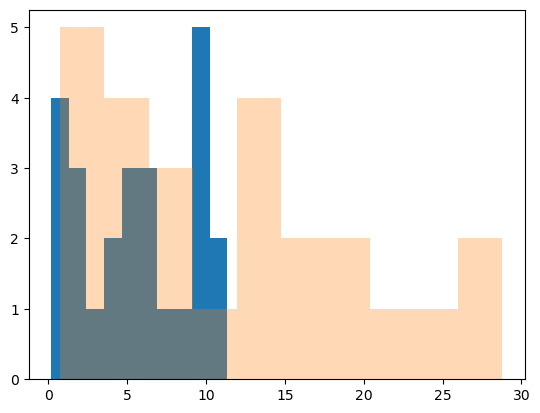

In [3]:
plt.hist(task.f_in_)
plt.hist(task.f_out_, alpha=0.3)

Text(0.5, 1.0, 'Mean outlier trajectory')

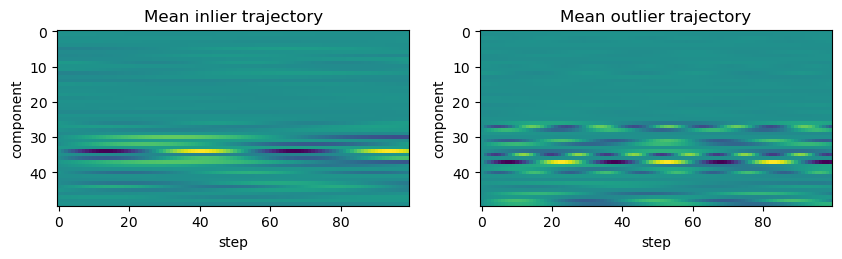

In [96]:
# mean over batch, visualized as an imshow
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(x_te[~y].mean(axis=0).T)
ax[0].set_xlabel('step')
ax[0].set_ylabel('component')
ax[0].set_title('Mean inlier trajectory')
ax[1].imshow(x_te[y].mean(axis=0).T)
ax[1].set_xlabel('step')
ax[1].set_ylabel('component')
ax[1].set_title('Mean outlier trajectory')

Text(0.5, 1.0, 'Outliers samples (averaged over components)')

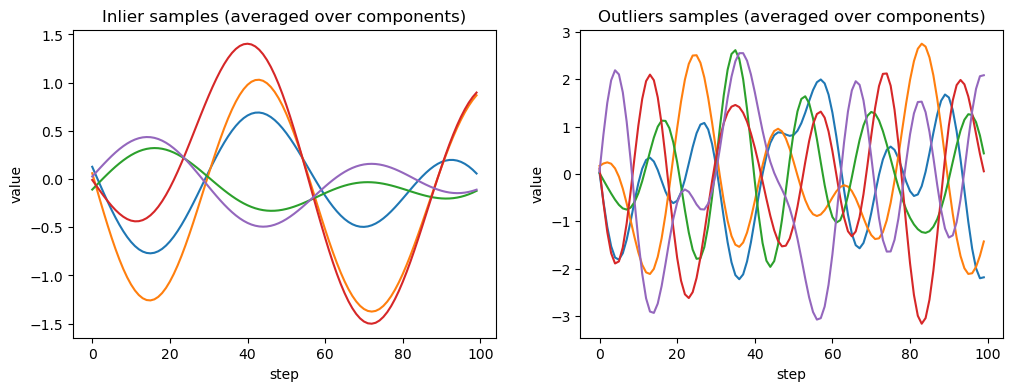

In [101]:
# mean over channels
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(x_te[~y][:5].mean(axis=-1).T);
ax[0].set_xlabel('step')
ax[0].set_ylabel('value')
ax[0].set_title('Inlier samples (averaged over components)')
ax[1].plot(x_te[y][:5].mean(axis=-1).T);
ax[1].set_xlabel('step')
ax[1].set_ylabel('value')
ax[1].set_title('Outliers samples (averaged over components)')

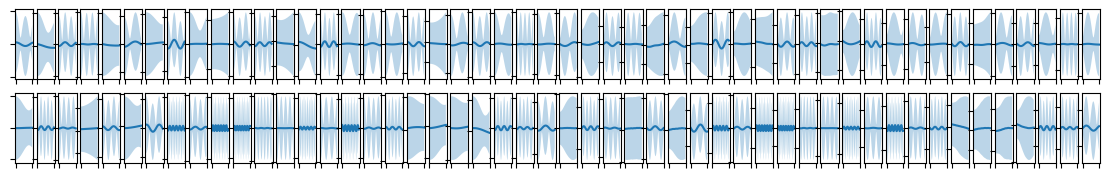

In [6]:
# mean over batch, for each channel separately
C = x_te.shape[-1]
fig, ax = plt.subplots(2, C, figsize=(14, 2))

for i in range(C):
    x = x_te[~y][..., i]
    mu = x.mean(axis=0)
    std = x.std(axis=0)
    ax[0, i].plot(mu)
    ax[0, i].fill_between(x=range(len(mu)), y1=mu-std, y2=mu+std, alpha=0.3)
    ax[0, i].set_xticklabels([])
    ax[0, i].set_yticklabels([])

for i in range(C):
    x = x_te[y][..., i]
    mu = x.mean(axis=0)
    std = x.std(axis=0)
    ax[1, i].plot(mu)
    ax[1, i].fill_between(x=range(len(mu)), y1=mu-std, y2=mu+std, alpha=0.3)
    ax[1, i].set_xticklabels([])
    ax[1, i].set_yticklabels([])

## Anomaly detection

In [80]:
from algs.kernels import GaussFFT
from algs.kern_cd import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score
import copy

In [ ]:
def eval(x_tr, x_te, n_trials=3):
    scores = []
    for i in range(n_trials):
        x_tr_trial, x_cal = train_test_split(x_tr, test_size=0.3)
        model = KernCD(GaussFFT(gamma=0.05), lam=1e-5).fit(x_tr_trial)

        q = np.quantile(model.predict(x_cal), q=0.95)
        y_pred = model.predict(x_te) > q

        scores.append(confusion_matrix(y, y_pred, normalize='true').flatten())
    scores = np.stack(scores)
    mu, std = scores.mean(axis=0), scores.std(axis=0)
    return mu, std / np.sqrt(n_trials)

In [75]:
eval(x_tr, x_te, 5)

(array([0.924, 0.076, 0.   , 1.   ]),
 array([0.02027018, 0.02027018, 0.        , 0.        ]))

interesting:
- effect of amount of data
- effect of lambda
- effect of coupling

In [98]:
def coupling_exp(n_trials=5):
    couplings = np.linspace(0, 10, num=15)
    cfgs = []
    for coup in couplings:
        new_cfg = copy.copy(cfg)
        new_cfg.coupling = coup
        cfgs.append(new_cfg)

    scores = np.zeros((len(cfgs), n_trials))
    for i, this_cfg in enumerate(cfgs):
        for j in range(n_trials):
            task = CoupledLinearOsc(this_cfg)
            x_tr, x_te, y = task.get_train_test()

            model = KernCD(GaussFFT(gamma=0.05), lam=1e-5).fit(x_tr)
            y_pred = model.predict(x_te)

            scores[i,j] = roc_auc_score(y, y_pred)

    return scores

In [99]:
scores = coupling_exp()

Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)
Gen. train w/ shape (250, 100, 50) and test w/ s

Text(0.5, 1.0, 'coupling value vs score of kernelized CD polynomial')

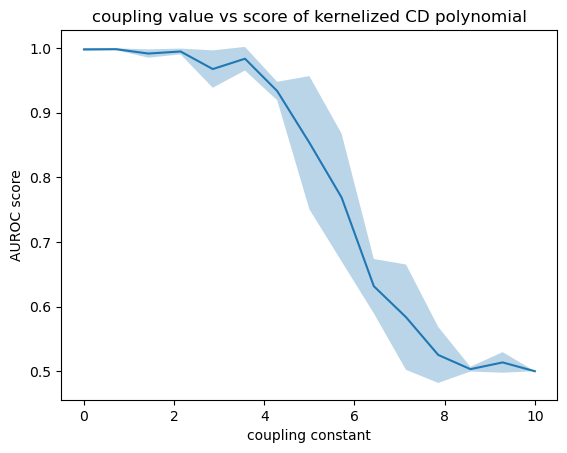

In [105]:
mu = scores.mean(axis=1)
std = scores.std(axis=1)

plt.fill_between(np.linspace(0, 10, num=15), mu-2*std/np.sqrt(5), mu+2*std/np.sqrt(5), alpha=0.3)
plt.plot(np.linspace(0, 10, num=15), mu)
plt.xlabel('coupling constant')
plt.ylabel('AUROC score')
plt.title('coupling value vs score of kernelized CD polynomial')